In [6]:
from mainnet_launch.constants import ROOT_PRICE_ORACLE, ETH_CHAIN
from mainnet_launch.abis import ROOT_PRICE_ORACLE_ABI
from mainnet_launch.data_fetching.get_events import fetch_events

contract = ETH_CHAIN.client.eth.contract(ROOT_PRICE_ORACLE(ETH_CHAIN), abi=ROOT_PRICE_ORACLE_ABI)
for e in contract.events:
    print(e)

PoolRegistered = fetch_events(contract.events.PoolRegistered, chain=ETH_CHAIN)
PoolRegistered

<class 'web3._utils.datatypes.PoolRegistered'>
<class 'web3._utils.datatypes.PoolRegistrationReplaced'>
<class 'web3._utils.datatypes.PoolRemoved'>
<class 'web3._utils.datatypes.SafeSpotPriceThresholdUpdated'>
<class 'web3._utils.datatypes.TokenRegistered'>
<class 'web3._utils.datatypes.TokenRegistrationReplaced'>
<class 'web3._utils.datatypes.TokenRemoved'>


,event,block,transaction_index,log_index,hash,pool,oracle
0,PoolRegistered,20648678,60,133,0x6ba21cf70de5a36ce1ec6bf959fdd76f3c0b76b0929c...,0x1E19CF2D73a72Ef1332C882F20534B6519Be0276,0x4D37d799a44515c25e43cA6ec9E4fF7a0a2a34d9
1,PoolRegistered,20648681,211,406,0x10dd9e2ad5fd82df22758224428d7fa040701aafccb6...,0xDACf5Fa19b1f720111609043ac67A9818262850c,0x7C19e64904ABA791dD653ECF7F355d65d7665a8b
2,PoolRegistered,20648688,121,394,0x4224569afba97bdca3bc3492134220fbce30dc911eef...,0x93d199263632a4EF4Bb438F1feB99e57b4b5f0BD,0x7C19e64904ABA791dD653ECF7F355d65d7665a8b
3,PoolRegistered,20648691,114,680,0xf8891ca410b18c39d7a63fc3fa7d184f9b7926abd0b0...,0xf01b0684C98CD7aDA480BFDF6e43876422fa1Fc1,0x4c70ef1DefFC14e8C0a3D5135EC8EbAfEFcC1c58
4,PoolRegistered,20648694,107,272,0x08832acc51f1e6894d8024229af7981d56b0ba192340...,0xF7A826D47c8E02835D94fb0Aa40F0cC9505cb134,0x4c70ef1DefFC14e8C0a3D5135EC8EbAfEFcC1c58
5,PoolRegistered,20648697,107,247,0x43e5535bd24502e0cb93488ecb7d5c1d383af796d762...,0xB91159aa527D4769CB9FAf3e4ADB760c7E8C8Ea7,0x7C19e64904ABA791dD653ECF7F355d65d7665a8b
6,PoolRegistered,20648700,141,421,0x8f144b9ca97cc866519573bb432f639b96c85d39f56b...,0x88794C65550DeB6b4087B7552eCf295113794410,0x7C19e64904ABA791dD653ECF7F355d65d7665a8b
7,PoolRegistered,20648703,82,195,0xec22b1f4c79425e69eda6b8232cccbbb2279506b3cb1...,0x596192bB6e41802428Ac943D2f1476C1Af25CC0E,0x7C19e64904ABA791dD653ECF7F355d65d7665a8b
8,PoolRegistered,20648706,133,358,0xb6446a119c63f392a4095be772e5ba5b79aef7cd9e50...,0x05ff47AFADa98a98982113758878F9A8B9FddA0a,0x7C19e64904ABA791dD653ECF7F355d65d7665a8b
9,PoolRegistered,20648709,112,241,0xd18be863d8d5254c0bd960bd6109f4ff0fdaf9f80f57...,0x848a5564158d84b8A8fb68ab5D004Fae11619A54,0x7C19e64904ABA791dD653ECF7F355d65d7665a8b


In [3]:
from stable_coin_pricing import stablecoin_constants, USDC
from multicall import Call
from mainnet_launch.data_fetching.get_state_by_block import *

In [ ]:
# double check that the borrow still works, on mainnet
# what happens to the spot price oracle, where there is no exit liqudity? eg 100% of it is borrowed

In [ ]:
# ind = 0, swaps = [{"amount":"1000000000000000","assetInIndex":"0","assetOutIndex":"1","poolId":"0xb819feef8f0fcdc268afe14162983a69f6bf179e000000000000000000000689","userData":"0x"}], assets = ["0x9d39a5de30e57443bff2a8307a4256c8797a3497","0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48"], funds = {"fromInternalBalance":false,"recipient":"0x7c19e64904aba791dd653ecf7f355d65d7665a8b","sender":"0x7c19e64904aba791dd653ecf7f355d65d7665a8b","toInternalBalance":false})

In [12]:
name_calls = [
    Call(
        pool,
        ["name()(string)"],
        [(pool, identity_with_bool_success)],
    )
    for pool in PoolRegistered["pool"].values
]
get_state_by_one_block(
    name_calls,
    22032711,
    ETH_CHAIN,
)

{'0x1E19CF2D73a72Ef1332C882F20534B6519Be0276': 'Balancer rETH Stable Pool',
 '0xDACf5Fa19b1f720111609043ac67A9818262850c': 'Balancer osETH/wETH StablePool',
 '0x93d199263632a4EF4Bb438F1feB99e57b4b5f0BD': 'Balancer wstETH-WETH Stable Pool',
 '0xf01b0684C98CD7aDA480BFDF6e43876422fa1Fc1': 'Gyroscope ECLP wstETH/wETH',
 '0xF7A826D47c8E02835D94fb0Aa40F0cC9505cb134': 'Gyroscope ECLP wstETH/cbETH',
 '0xB91159aa527D4769CB9FAf3e4ADB760c7E8C8Ea7': 'Balancer ETHx/wstETH',
 '0x88794C65550DeB6b4087B7552eCf295113794410': 'Balancer pxETH/wETH StablePool',
 '0x596192bB6e41802428Ac943D2f1476C1Af25CC0E': 'Balancer ezETH-WETH Stable Pool',
 '0x05ff47AFADa98a98982113758878F9A8B9FddA0a': 'Balancer weETH/rETH StablePool',
 '0x848a5564158d84b8A8fb68ab5D004Fae11619A54': 'Balancer weETH/ezETH/rswETH',
 '0x58AAdFB1Afac0ad7fca1148f3cdE6aEDF5236B6D': 'Balancer rsETH-WETH Stable Pool',
 '0x7761b6E0Daa04E70637D81f1Da7d186C205C2aDE': 'Balancer rsETH / ETHx',
 '0xe080027Bd47353b5D1639772b4a75E9Ed3658A0d': 'osETH/rETH

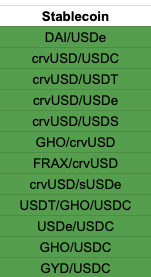

In [8]:
from multicall import Call
from mainnet_launch.constants import *

sellGem_call = Call(
    "0xA188EEC8F81263234dA3622A406892F3D630f98c",
    ["sellGem(address,uint256)(uint256)", "0xA188EEC8F81263234dA3622A406892F3D630f98c", int(1e18)],
    [("sellGem_output", safe_normalize_with_bool_success)],
)
get_state_by_one_block([sellGem_call], 22021700, ETH_CHAIN)

{'sellGem_output': None}

In [10]:
def _fee_to_usdc_amount(success: bool, fee_amount):
    if success:
        return 1 - (fee_amount / 1e18)


tout_call = Call(
    "0xA188EEC8F81263234dA3622A406892F3D630f98c",
    ["tout()(uint256)"],
    [("USDS_to_USDC_spot_price", _fee_to_usdc_amount)],
)

tin_call = Call(
    "0xA188EEC8F81263234dA3622A406892F3D630f98c", ["tin()(uint256)"], [("USDC_to_USDS_spot_price", _fee_to_usdc_amount)]
)


fee_calls = get_raw_state_by_blocks([tin_call, tout_call], build_blocks_to_use(ETH_CHAIN), ETH_CHAIN)
fee_calls
get_state_by_one_block([tin_call, tout_call], 22021700, ETH_CHAIN)

{'tin': 0, 'tout': 0}

In [7]:
from mainnet_launch.constants import *
from mainnet_launch.data_fetching.get_state_by_block import *
from mainnet_launch.data_fetching.get_state_by_block import _build_blocks_to_use_dont_clip
def _fee_to_usdc_amount(success: bool, fee_amount):
    return 1 - (fee_amount / 1e18)


tout_call = Call(
    "0xA188EEC8F81263234dA3622A406892F3D630f98c", ["tout()(uint256)"], [("tout", identity_with_bool_success)]
)

tin_call = Call("0xA188EEC8F81263234dA3622A406892F3D630f98c", ["tin()(uint256)"], [("tin", identity_with_bool_success)])


blocks = _build_blocks_to_use_dont_clip(ETH_CHAIN, start_block=17_000_000, approx_num_blocks_per_day=1)
df = get_raw_state_by_blocks([tin_call, tout_call], blocks, ETH_CHAIN)
df.to_csv('maker_dao_tin_tout.csv')

In [9]:
df.value_counts()

tin  tout
0.0  0.0     196
Name: count, dtype: int64

In [12]:
fee_calls.value_counts()

tin  tout
0    0       182
Name: count, dtype: int64

In [ ]:
# GHO, USDT, sUSEe

# sUSD, crv -> crv

# DAI -> USDe -> USDC

# crvUSD -> USDC

# USDS -> crvUSD -> USDC


# DAI -> USDe (then USDe -> USDC oracle)
#

In [ ]:
# {'0x6B175474E89094C44Da98b954EedeAC495271d0F DAI': 1.006586,
#  '0x4c9EDD5852cd905f086C759E8383e09bff1E68B3 USDe': None,
#  '0xA0b86991c6218b36c1d19D4a2e9Eb0cE3606eB48 USDC': 1.0,
#  '0xdAC17F958D2ee523a2206206994597C13D831ec7 USDT': 0.998533,
#  '0xdC035D45d973E3EC169d2276DDab16f1e407384F USDs': 0.997547,
#  '0x40D16FC0246aD3160Ccc09B8D0D3A2cD28aE6C2f GHO': 0.997494,
#  '0xf939E0A03FB07F59A73314E73794Be0E57ac1b4E crvUSD': 0.997428,
#  '0x0655977FEb2f289A4aB78af67BAB0d17aAb84367 scrvUSD': 1.03902,
#  '0x9D39A5DE30e57443BfF2A8307A4256c8797A3497 sUSDe': 1.155932,
# #  '0xa3931d71877C0E7a3148CB7Eb4463524FEc27fbD sUSDs': 1.040242}

In [ ]:
# def use_tokemak_pri e

# return Call(
#     tokemak_pool_oracle,
#     ["getSpotPrice(address,address,address)((uint256,address))", token, pool, requestedQuoteToken],
#     [("DAI_to_USDC_spot_price2", safe_normalize_6_with_bool_success)],
# )

In [4]:
PoolRegistered["oracle"].value_counts()

oracle
0x7C19e64904ABA791dD653ECF7F355d65d7665a8b    10
0xaeD535d737e80597452d1f04D1b64b4f2Ab8A92b     8
0x8e9A06F85A3d188f2a851d1b4fb582680727A5D7     5
0x4c70ef1DefFC14e8C0a3D5135EC8EbAfEFcC1c58     2
0x4D37d799a44515c25e43cA6ec9E4fF7a0a2a34d9     1
0x1140CD28E7b8E6B6509761f0BBbFa88AbBe8421B     1
Name: count, dtype: int64